# Optimization + Simulation: The Two-Step Workflow

This notebook is written for **business and analytics students**, not programmers. Treat Python as a **calculator and charting assistant**. Your learning goal is to understand the **two-step reasoning**: get a principled plan from optimization, then **stress-test** that plan (and alternatives) with simulation.

This notebook demonstrates how to combine optimization and simulation into a two-step process for making robust decisions under uncertainty.

Understanding this is critical because:
- **Optimization finds the best plan given your assumptions** — but assumptions can be wrong
- **Simulation tests the plan under real-world variation** — revealing how often it actually works
- **Neither tool alone is sufficient** — optimization without simulation can be overconfident; simulation without optimization can waste time on arbitrary plans
- **Together, they answer a better question:** not only "what is optimal under a forecast?" but "which plan holds up when the forecast is wrong?"

**How to use this notebook:** run cells top to bottom. When you see `pulp`, that is Python calling a **solver** that finds a good production quantity under explicit rules you gave it.


## Key Concepts

**The optimize-then-simulate workflow:**
1. Frame the decision and build an optimization model
2. Solve it — get the recommended plan under fixed assumptions
3. Identify which inputs are genuinely uncertain
4. Run Monte Carlo simulation using those uncertainties
5. Evaluate — does the recommended plan hold up across scenarios?
6. If not, adjust constraints or objectives and repeat

**Comparing candidate plans side by side:**  
Instead of asking only "which plan is cheapest under a single forecast?", simulation lets you ask "which plan behaves best **across many plausible futures**?"  
A slightly more expensive plan that avoids terrible weeks can beat a "optimal" plan that gambles on the forecast being exactly right.

**Percentiles in this notebook:** we use **P10** and **P90** of weekly profit as simple summaries of bad-week vs good-week outcomes.

**Connection to concept01:** concept01 ran simulation for staffing levels. Here we **first optimize** under a fixed demand assumption, then **simulate** that optimized quantity alongside alternative quantities under uncertain demand.


## Scenario: Production Planning Under Demand Uncertainty

A manufacturing manager must decide how much to produce each week.

- Products sell for **$80/unit**; variable production cost is **$50/unit** (gross margin = $30/unit sold)
- Unsold units incur a **$15/unit holding cost**
- Unmet demand costs **$25/unit** in lost margin and customer goodwill
- Production capacity is **1,200 units/week**

The optimizer will suggest a production quantity. Simulation will then reveal whether that quantity actually performs well when demand varies.

## Step 1: Install Required Packages

**What you are doing:** installing `pulp`, a Python layer that builds optimization models and sends them to a solver, plus the usual numeric/plotting libraries.

**Why `pulp` matters here:** the notebook's optimization step is not hand-waved — it is a real constrained optimization, just small enough to read.


In [1]:
%pip install numpy matplotlib pandas pulp -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

**What each piece is for:**
- **`numpy` / `pandas` / `matplotlib`**: random demand scenarios, tables, and histograms
- **`pulp`**: defines the optimization problem (decision variable, objective, constraints) and solves it

**`warnings.filterwarnings('ignore')`** hides noisy technical warnings so the output stays readable for class. It does not change the solution logic.

**`np.random.seed(42)`** keeps the demand simulation repeatable for teaching.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, value, PULP_CBC_CMD
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 3: Step 1 — Optimize

**Story:** the production manager has a **point forecast** of demand (1,000 units/week). The optimizer believes that number as if it were certain, and chooses a production quantity to maximize a simple weekly profit expression.

**What the code is doing (read slowly):**
- It defines `produce`, the decision variable: how many units to manufacture this week (bounded by capacity).
- The objective adds **profit_per_unit * produce** — this is a simplified "sell everything you produce" profit line (the simulation later adds holding and unmet-demand costs when demand varies).
- Constraints enforce `produce ≤ demand_estimate` and `produce ≤ capacity`.
- `model.solve(...)` asks the solver for the best feasible quantity.

**What to look for:** the solver will recommend producing up to the forecast (here, 1,000) because, under the fixed forecast, making more would not increase sales in this toy objective.

**The punchline (before simulation):** the optimizer did its job **given what it was told**. The next step asks what happens when demand is not fixed.


In [3]:
# === STEP 1: OPTIMIZE ===
# Parameters (best estimates — treated as certain by the optimizer)
demand_estimate  = 1_000   # units/week (manager's best forecast)
capacity         = 1_200   # max production/week
profit_per_unit  = 30      # $/unit sold
holding_cost     = 15      # $/unit unsold
unmet_cost       = 25      # $/unit of unmet demand

# Build optimization model
model   = LpProblem('Production_Planning', LpMaximize)
produce = LpVariable('produce', lowBound=0, upBound=capacity, cat='Continuous')

# Objective: maximize net profit under fixed demand
model += profit_per_unit * produce
model += produce <= demand_estimate, 'Demand_Cap'
model += produce <= capacity,        'Capacity'

model.solve(PULP_CBC_CMD(msg=0))
optimal_qty            = value(produce)
optimal_profit_estimate = value(model.objective)

print("=== OPTIMIZATION RESULT ===")
print(f"Recommended production quantity: {optimal_qty:,.0f} units")
print(f"Estimated profit (under fixed demand): ${optimal_profit_estimate:,.0f}")
print()
print("The optimizer sees demand as fixed at 1,000 units.")
print("It recommends producing exactly 1,000 units to maximize profit.")
print()
print("But demand is NOT fixed. Next we test this recommendation under uncertainty.")

=== OPTIMIZATION RESULT ===
Recommended production quantity: 1,000 units
Estimated profit (under fixed demand): $30,000

The optimizer sees demand as fixed at 1,000 units.
It recommends producing exactly 1,000 units to maximize profit.

But demand is NOT fixed. Next we test this recommendation under uncertainty.


## Step 4: Step 2 — Simulate

**Story:** we generate **the same 1,000 demand futures** for every plan so the comparison is fair. Then we score three production quantities: a lean plan, the "optimal" plan from Step 3, and a buffered plan.

**What `simulate_plan` means in business terms:**
- If you produce more than demand, some units are **unsold** → holding cost.
- If you produce less than demand, some demand is **unmet** → shortage / goodwill cost.
- Profit is revenue-like gains from units sold, minus those mismatch costs.

**After you run it:** compare **mean profit** (typical performance) with **P10 profit** (roughly a bad-week metric) and **% Loss** (fraction of weeks below zero profit). Two plans can look similar on average but very different in the tails.


In [4]:
# === STEP 2: SIMULATE ===
n_scenarios  = 1_000
demand_mean  = 1_000
demand_std   = 150   # realistic variation: +/-150 units around forecast

# Three candidate plans to compare
candidate_plans = {
    'Lean (900 units)':      900,
    'Optimal (1,000 units)': int(optimal_qty),
    'Buffer (1,100 units)':  1_100,
}

def simulate_plan(qty, demands):
    units_sold  = np.minimum(qty, demands)
    units_held  = np.maximum(0, qty - demands)
    units_unmet = np.maximum(0, demands - qty)
    return profit_per_unit * units_sold - holding_cost * units_held - unmet_cost * units_unmet

# Same demand scenarios for every plan (fair comparison)
demand_scenarios = np.random.normal(demand_mean, demand_std, n_scenarios)
demand_scenarios = np.clip(demand_scenarios, 0, None)

simulation_results = {}
for plan_name, qty in candidate_plans.items():
    profits = simulate_plan(qty, demand_scenarios)
    simulation_results[plan_name] = {
        'qty':         qty,
        'mean_profit': np.mean(profits),
        'p10_profit':  np.percentile(profits, 10),
        'p90_profit':  np.percentile(profits, 90),
        'pct_loss':    np.mean(profits < 0) * 100,
        'all_profits': profits,
    }

print("Simulation complete.")
print()
print(f"{'Plan':<25} {'Qty':>6} {'Mean Profit':>13} {'P10 (bad day)':>15} {'P90 (good day)':>16} {'% Loss':>8}")
print("-" * 88)
for name, r in simulation_results.items():
    print(f"{name:<25} {r['qty']:>6,} ${r['mean_profit']:>11,.0f} "
          f"${r['p10_profit']:>13,.0f} ${r['p90_profit']:>14,.0f}  {r['pct_loss']:>5.1f}%")

if all(r['pct_loss'] == 0 for r in simulation_results.values()):
    print("\nNote: 0.0% loss is expected under this parameter set.")
    print("Demand variation is modest relative to unit margin and mismatch costs, so profits stay above $0.")
    print("To stress-test downside risk, increase demand_std or raise mismatch costs.")

Simulation complete.

Plan                         Qty   Mean Profit   P10 (bad day)   P90 (good day)   % Loss
----------------------------------------------------------------------------------------
Lean (900 units)             900 $     23,009 $       18,895 $        26,337    0.0%
Optimal (1,000 units)      1,000 $     25,937 $       21,289 $        29,437    0.0%
Buffer (1,100 units)       1,100 $     27,038 $       20,098 $        32,304    0.0%

Note: 0.0% loss is expected under this parameter set.
Demand variation is modest relative to unit margin and mismatch costs, so profits stay above $0.
To stress-test downside risk, increase demand_std or raise mismatch costs.


## Step 5: Visualize the Plan Comparison

**What the histograms show:** the distribution of weekly profit for each candidate plan under the same simulated demands.

**How to read the markings:**
- **Mean** (dashed black): typical week
- **P10** (dotted red): many managers care about this left tail — "how bad can a bad week be?"
- **Orange vertical line at $0**: separates profitable vs losing weeks in this simplified accounting

**What the grouped bar chart adds:** it compresses each plan into three landmarks — P10, mean, P90 — so you can compare tail risk quickly.

**Interpretation habit:** if a plan has a nice mean but a rough P10, ask whether the business can survive a run of bad weeks.


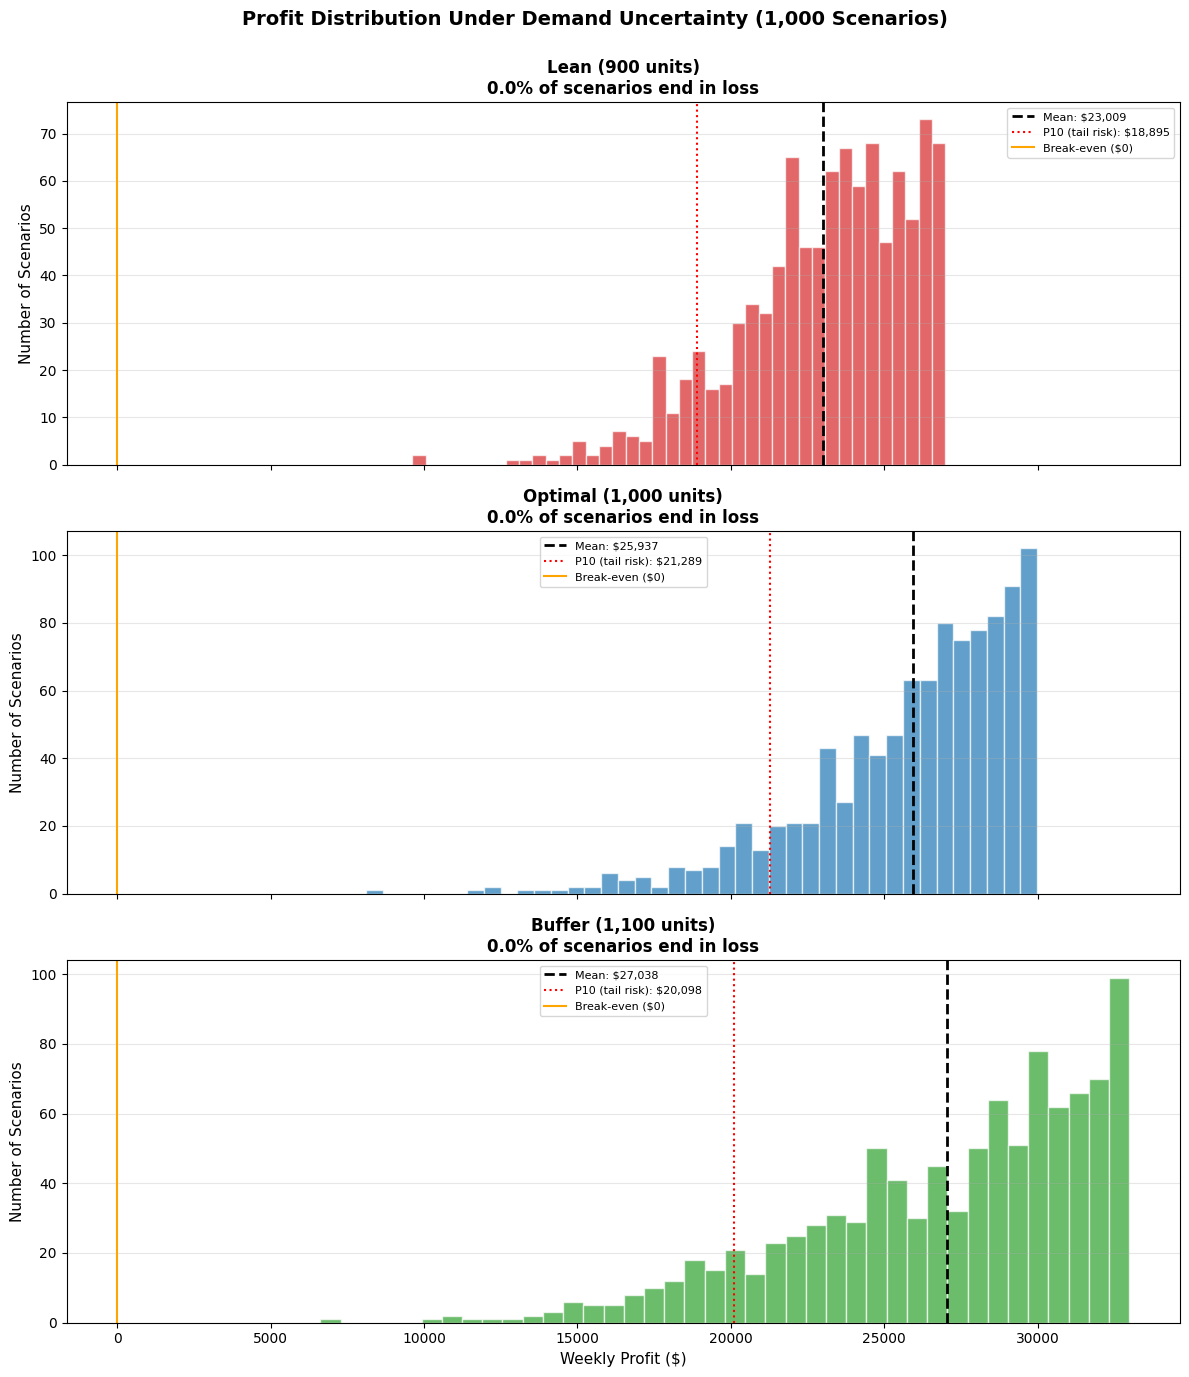

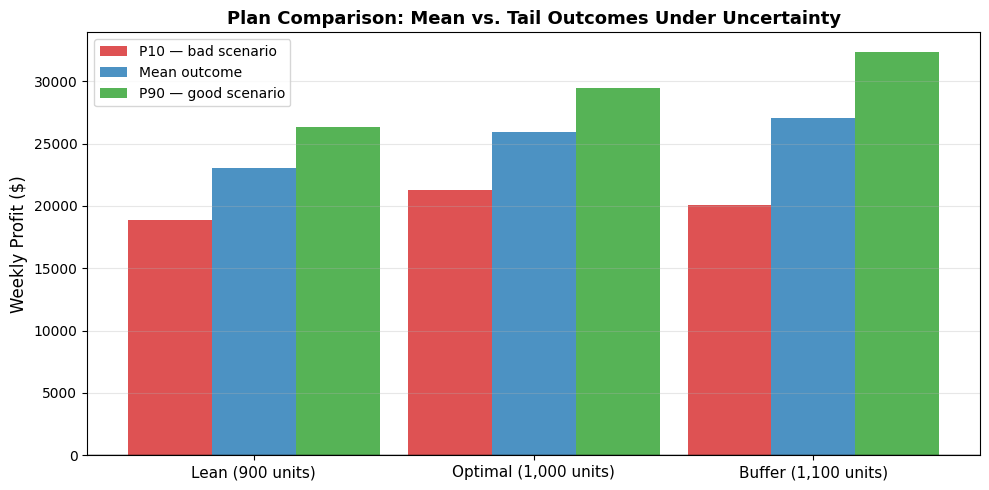

In [5]:
# === VISUALIZATION: OUTCOME DISTRIBUTIONS ===
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
colors     = ['#d62728', '#1f77b4', '#2ca02c']

for idx, (name, r) in enumerate(simulation_results.items()):
    ax = axes[idx]
    profits = r['all_profits']
    ax.hist(profits, bins=40, color=colors[idx], alpha=0.7, edgecolor='white')
    ax.axvline(r['mean_profit'], color='black',  linestyle='--', lw=2,
               label=f"Mean: ${r['mean_profit']:,.0f}")
    ax.axvline(r['p10_profit'],  color='red',    linestyle=':',  lw=1.5,
               label=f"P10 (tail risk): ${r['p10_profit']:,.0f}")
    ax.axvline(0,                color='orange', linestyle='-',  lw=1.5,
               label='Break-even ($0)')
    ax.set_title(f"{name}\n{r['pct_loss']:.1f}% of scenarios end in loss",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Scenarios', fontsize=11)
    if idx == len(simulation_results) - 1:
        ax.set_xlabel('Weekly Profit ($)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Profit Distribution Under Demand Uncertainty (1,000 Scenarios)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# === SUMMARY BAR CHART ===
fig, ax = plt.subplots(figsize=(10, 5))
plan_names = list(simulation_results.keys())
x     = np.arange(len(plan_names))
width = 0.3
means = [simulation_results[n]['mean_profit'] for n in plan_names]
p10s  = [simulation_results[n]['p10_profit']  for n in plan_names]
p90s  = [simulation_results[n]['p90_profit']  for n in plan_names]

ax.bar(x - width, p10s,  width, label='P10 — bad scenario',  color='#d62728', alpha=0.8)
ax.bar(x,         means, width, label='Mean outcome',         color='#1f77b4', alpha=0.8)
ax.bar(x + width, p90s,  width, label='P90 — good scenario', color='#2ca02c', alpha=0.8)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(plan_names, fontsize=11)
ax.set_ylabel('Weekly Profit ($)', fontsize=12)
ax.set_title('Plan Comparison: Mean vs. Tail Outcomes Under Uncertainty',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Apply Judgment to the Comparison

**What this step is doing:** no new math — just guided reading of the simulation you already computed.

**Important nuance:** mean profit and **P10 profit** (a simple "bad week" summary) do not always rank plans the same way. The code cell below **reads your table** and reports which plan has the best and worst P10 in *this* run. Your job is to explain *why* that ranking makes sense given holding vs unmet-demand costs.

**Managerial questions to practice answering:**
- Are we optimizing for average quarterly profit, or avoiding catastrophic weeks?
- Do we have working capital to carry extra inventory if we buffer?
- How trustworthy is the demand forecast — and what happens if it is systematically wrong, not just noisy?


In [6]:
print("=== DECISION FRAMEWORK: WHICH PLAN IS BEST? ===")
print()
print("Optimization says: 'Produce 1,000 units — maximizes profit under assumed demand.'")
print()
for name, r in simulation_results.items():
    print(f"Plan: {name}")
    print(f"  Mean profit:       ${r['mean_profit']:>10,.0f}")
    print(f"  Worst 10% of days: ${r['p10_profit']:>10,.0f}  <- tail risk")
    print(f"  Best 10% of days:  ${r['p90_profit']:>10,.0f}")
    print(f"  Loss scenarios:    {r['pct_loss']:>5.1f}%")
    print()
print("Questions the manager must answer:")
print("  1. Is the mean improvement from the Buffer plan worth its tail risk?")
print("  2. How costly is a loss scenario — cash reserves, customer relationships?")
print("  3. Does the business have the working capital to absorb bad weeks?")
print()
print("Key insight: the optimizer identified 1,000 units as 'optimal' under a fixed forecast.")
print("Simulation shows the three plans do not have the same downside protection.")
best_p10 = max(simulation_results.items(), key=lambda kv: kv[1]["p10_profit"])
worst_p10 = min(simulation_results.items(), key=lambda kv: kv[1]["p10_profit"])
print(
    f"In this run, the highest P10 profit (gentler bad weeks) is '{best_p10[0]}' "
    f"at ${best_p10[1]['p10_profit']:,.0f}."
)
print(
    f"The lowest P10 profit (harsher bad weeks) is '{worst_p10[0]}' "
    f"at ${worst_p10[1]['p10_profit']:,.0f}."
)
print("A risk-averse manager cares about that left tail — not only the mean.")
print()
print("This is what simulation adds: not a better answer, but a clearer picture.")

=== DECISION FRAMEWORK: WHICH PLAN IS BEST? ===

Optimization says: 'Produce 1,000 units — maximizes profit under assumed demand.'

Plan: Lean (900 units)
  Mean profit:       $    23,009
  Worst 10% of days: $    18,895  <- tail risk
  Best 10% of days:  $    26,337
  Loss scenarios:      0.0%

Plan: Optimal (1,000 units)
  Mean profit:       $    25,937
  Worst 10% of days: $    21,289  <- tail risk
  Best 10% of days:  $    29,437
  Loss scenarios:      0.0%

Plan: Buffer (1,100 units)
  Mean profit:       $    27,038
  Worst 10% of days: $    20,098  <- tail risk
  Best 10% of days:  $    32,304
  Loss scenarios:      0.0%

Questions the manager must answer:
  1. Is the mean improvement from the Buffer plan worth its tail risk?
  2. How costly is a loss scenario — cash reserves, customer relationships?
  3. Does the business have the working capital to absorb bad weeks?

Key insight: the optimizer identified 1,000 units as 'optimal' under a fixed forecast.
Simulation shows the thre

## Key Takeaways (Outro)

1. **Optimize first, then simulate.** Optimization proposes a structured starting point; simulation tests whether that proposal is **fragile** when assumptions wiggle.

2. **Fair comparisons use the same scenarios.** Using identical simulated demands for each plan prevents "cherry-picked futures."

3. **Mean outcome alone is incomplete.** Tail risk (like P10 profit) often drives real operations decisions.

4. **Common mistakes to avoid:**
   - Simulating random plans without ever optimizing (you can miss obviously good structure)
   - Running too few scenarios (noise can mislead; thousands is a common teaching default)
   - Treating simulation output as the final decision rather than **evidence** for a human decision

5. **The better question:** not only "what should we produce?" but "how robust is this production policy, and what breaks it?"

**Next notebook:** machine learning forecasts feeding optimization — where the handoff between prediction and decision can fail even when each step looks "reasonable" alone.
